In [1]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
df = pd.read_csv('ruangguru_cleaned_balanced.csv')

In [9]:
df = pd.read_csv('ruangguru_cleaned_balanced.csv')
df = df.dropna(subset=['clean_text', 'label'])

df['label_num'] = df['label'].map({'Negatif': 0, 'Positif': 1})

teks_bin = df['clean_text'].astype(str).values
label_bin = df['label_num'].values

In [10]:
teks_latih, teks_test, label_latih, label_test = train_test_split(
    teks_bin, label_bin, test_size=0.2, random_state=42
)

vocab_size = 10000
max_length = 80

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(teks_latih)

padded_latih = pad_sequences(tokenizer.texts_to_sequences(teks_latih), maxlen=max_length, padding='post', truncating='post')
padded_test = pad_sequences(tokenizer.texts_to_sequences(teks_test), maxlen=max_length, padding='post', truncating='post')

In [12]:
tf.keras.backend.clear_session()

model_goldilocks = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001, verbose=1)

model_goldilocks.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_goldilocks.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 80, 128)        │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 714,369 (2.73 MB)

 Trainable params: 714,369 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model_goldilocks.fit(
    padded_latih, label_latih,
    epochs=50,
    batch_size=128,
    validation_data=(padded_test, label_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7161 - loss: 0.5375 - val_accuracy: 0.8540 - val_loss: 0.3743 - learning_rate: 0.0010
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8614 - loss: 0.3685 - val_accuracy: 0.8254 - val_loss: 0.4273 - learning_rate: 0.0010
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8826 - loss: 0.3288 - val_accuracy: 0.8684 - val_loss: 0.3560 - learning_rate: 0.0010
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8951 - loss: 0.2963 - val_accuracy: 0.8654 - val_loss: 0.3460 - learning_rate: 0.0010
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9017 - loss: 0.2821 - val_accuracy: 0.8632 - val_loss: 0.3476 - learning_rate: 0.0010
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9118 - loss: 0.2559 - val_accuracy: 0.8586 - val_loss: 0.3593 - learning_rate: 0.0010
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9188 - loss: 0.

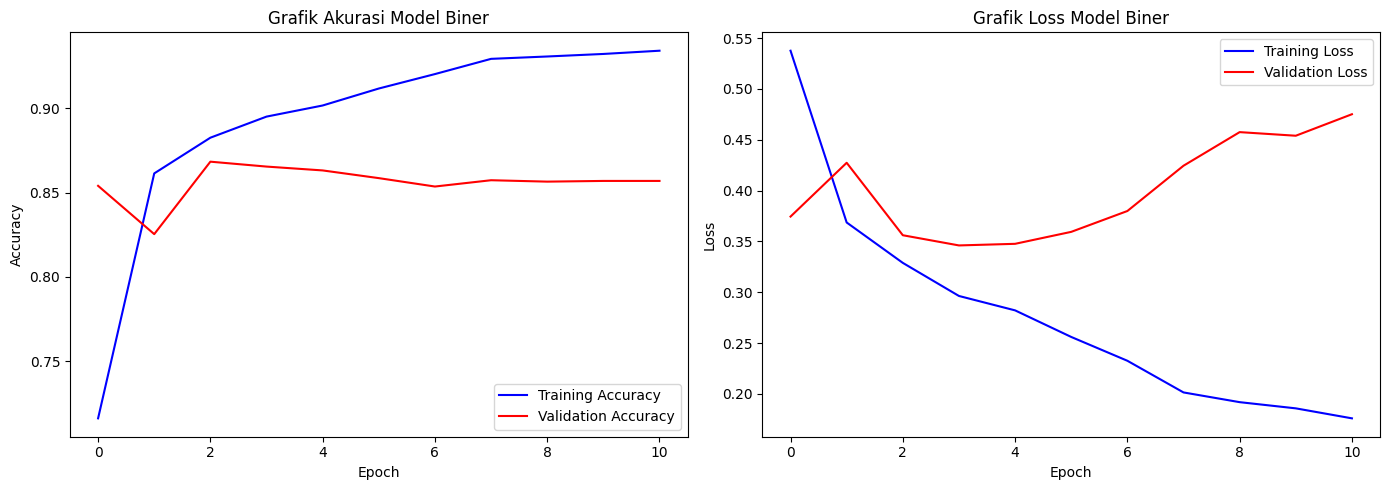

In [15]:
import matplotlib.pyplot as plt

# Membuat visualisasi pergerakan akurasi (Accuracy)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Grafik Akurasi Model Biner')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Membuat visualisasi pergerakan tingkat kesalahan (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Grafik Loss Model Biner')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [16]:
model_goldilocks.save('model_sentimen_pendidikan.h5')

In [17]:
import numpy as np

teks_testing = [
    "Wah gila sih ini ngebantu banget buat belajar matematika, makasih banget ruang guru!",
    "Masa video materinya gak bisa diputar, rugi banget udah langganan mahal-mahal tapi aplikasinya lemot terus"
]

sekuens_testing = tokenizer.texts_to_sequences(teks_testing)

padded_testing = pad_sequences(sekuens_testing, maxlen=max_length, padding='post', truncating='post')

prediksi = model_goldilocks.predict(padded_testing)

print("\n" + "=" * 50)
print("HASIL UJI COBA MODEL AI SENTIMEN RUANGGURU")
print("=" * 50)

for i in range(len(teks_testing)):
    sentimen = "Positif" if prediksi[i][0] > 0.5 else "Negatif"
    keyakinan = prediksi[i][0] * 100 if sentimen == "Positif" else (1 - prediksi[i][0]) * 100

    print(f"Komentar : '{teks_testing[i]}'")
    print(f"Prediksi : {sentimen}")
    print(f"Tingkat Keyakinan : {keyakinan:.2f}%")
    print("-" * 50)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step

HASIL UJI COBA MODEL AI SENTIMEN RUANGGURU
Komentar : 'Wah gila sih ini ngebantu banget buat belajar matematika, makasih banget ruang guru!'
Prediksi : Positif
Tingkat Keyakinan : 88.09%
--------------------------------------------------
Komentar : 'Masa video materinya gak bisa diputar, rugi banget udah langganan mahal-mahal tapi aplikasinya lemot terus'
Prediksi : Negatif
Tingkat Keyakinan : 89.36%
--------------------------------------------------


In [18]:
import json
word_index = tokenizer.word_index
top_words = {k: v for k, v in word_index.items() if v < 2000}
print(json.dumps(top_words))

{"<OOV>": 1, "ruang": 2, "guru": 3, "ajar": 4, "bagus": 5, "banget": 6, "bantu": 7, "gak": 8, "kasih": 9, "bayar": 10, "nilai": 11, "tolong": 12, "mudah": 13, "suka": 14, "udah": 15, "video": 16, "langgan": 17, "ga": 18, "terima": 19, "download": 20, "tv": 21, "paham": 22, "gk": 23, "anak": 24, "buka": 25, "kalo": 26, "kak": 27, "materi": 28, "terimakasih": 29, "apk": 30, "bintang": 31, "kelas": 32, "baik": 33, "aplikasi": 34, "pas": 35, "pakai": 36, "smk": 37, "ku": 38, "sekolah": 39, "pake": 40, "orang": 41, "masuk": 42, "nonton": 43, "erti": 44, "mohon": 45, "coba": 46, "karna": 47, "bikin": 48, "gratis": 49, "iklan": 50, "nggak": 51, "moga": 52, "gimana": 53, "maaf": 54, "tau": 55, "makasih": 56, "manfaat": 57, "deh": 58, "hp": 59, "paket": 60, "gw": 61, "udh": 62, "kali": 63, "pintar": 64, "online": 65, "daftar": 66, "senang": 67, "mahal": 68, "ulang": 69, "susah": 70, "semangat": 71, "bimbel": 72, "sy": 73, "keren": 74, "gua": 75, "seru": 76, "latih": 77, "indonesia": 78, "nama":